# Phase 1: Data Ingestion, Exploratory Data Analysis & Feature Engineering
**Flight Delay Prediction System (SkyAware Project)**  
**AAI-540 — Machine Learning Operations (MLOps)**

In [1]:
!pip install sagemaker==2.224.2

In [2]:
import sagemaker
import boto3
import os

# 1. Initialize Session
sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()

# 2. S3 URI
RAW_DATA_URI = f"s3://{bucket}/skyaware-raw-data"

# 3. filename
local_file_name = "Airline_Delay_Cause.csv"

# Check if the file exists in the notebook first
if os.path.exists(local_file_name):
    print(f"Found {local_file_name} locally. Uploading to S3...")
    
    # Upload to S3 using the AWS CLI for efficiency
    !aws s3 cp {local_file_name} {RAW_DATA_URI}/{local_file_name}
    
    print(f"SUCCESS: File is now at {RAW_DATA_URI}/{local_file_name}")
else:
    print(f"ERROR: Could not find {local_file_name} in the notebook folder. Please upload it using the arrow icon first.")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Found Airline_Delay_Cause.csv locally. Uploading to S3...


Completed 1.0 MiB/50.7 MiB (10.2 MiB/s) with 1 file(s) remaining
Completed 2.0 MiB/50.7 MiB (19.5 MiB/s) with 1 file(s) remaining
Completed 3.0 MiB/50.7 MiB (28.7 MiB/s) with 1 file(s) remaining
Completed 4.0 MiB/50.7 MiB (37.0 MiB/s) with 1 file(s) remaining
Completed 5.0 MiB/50.7 MiB (45.3 MiB/s) with 1 file(s) remaining


Completed 7.0 MiB/50.7 MiB (60.9 MiB/s) with 1 file(s) remaining


Completed 9.0 MiB/50.7 MiB (52.2 MiB/s) with 1 file(s) remaining
Completed 10.0 MiB/50.7 MiB (56.3 MiB/s) with 1 file(s) remaining
Completed 11.0 MiB/50.7 MiB (61.3 MiB/s) with 1 file(s) remaining
Completed 12.0 MiB/50.7 MiB (66.2 MiB/s) with 1 file(s) remaining
Completed 13.0 MiB/50.7 MiB (70.7 MiB/s) with 1 file(s) remaining
Completed 14.0 MiB/50.7 MiB (75.6 MiB/s) with 1 file(s) remaining
Completed 15.0 MiB/50.7 MiB (79.0 MiB/s) with 1 file(s) remaining
Completed 16.0 MiB/50.7 MiB (83.8 MiB/s) with 1 file(s) remaining
Completed 17.0 MiB/50.7 MiB (87.8 MiB/s) with 1 file(s) remaining
Completed 18.0 MiB/50.7 MiB (92.6 MiB/s) with 1 file(s) remaining
Completed 19.0 MiB/50.7 MiB (95.2 MiB/s) with 1 file(s) remaining
Completed 20.0 MiB/50.7 MiB (100.2 MiB/s) with 1 file(s) remaining
Completed 21.0 MiB/50.7 MiB (105.0 MiB/s) with 1 file(s) remaining
Completed 22.0 MiB/50.7 MiB (107.0 MiB/s) with 1 file(s) remaining
Completed 23.0 MiB/50.7 MiB (111.1 MiB/s) with 1 file(s) remaining
Complet

Completed 26.0 MiB/50.7 MiB (120.7 MiB/s) with 1 file(s) remaining
Completed 27.0 MiB/50.7 MiB (124.6 MiB/s) with 1 file(s) remaining
Completed 28.0 MiB/50.7 MiB (128.5 MiB/s) with 1 file(s) remaining
Completed 28.7 MiB/50.7 MiB (130.1 MiB/s) with 1 file(s) remaining
Completed 29.7 MiB/50.7 MiB (134.5 MiB/s) with 1 file(s) remaining
Completed 30.7 MiB/50.7 MiB (136.6 MiB/s) with 1 file(s) remaining
Completed 31.7 MiB/50.7 MiB (141.0 MiB/s) with 1 file(s) remaining
Completed 32.7 MiB/50.7 MiB (142.5 MiB/s) with 1 file(s) remaining
Completed 33.7 MiB/50.7 MiB (146.1 MiB/s) with 1 file(s) remaining
Completed 34.7 MiB/50.7 MiB (148.7 MiB/s) with 1 file(s) remaining
Completed 35.7 MiB/50.7 MiB (151.8 MiB/s) with 1 file(s) remaining
Completed 36.7 MiB/50.7 MiB (155.9 MiB/s) with 1 file(s) remaining
Completed 37.7 MiB/50.7 MiB (158.4 MiB/s) with 1 file(s) remaining
Completed 38.7 MiB/50.7 MiB (161.4 MiB/s) with 1 file(s) remaining
Completed 39.7 MiB/50.7 MiB (164.3 MiB/s) with 1 file(s) remai

upload: ./Airline_Delay_Cause.csv to s3://sagemaker-us-east-1-395523713934/skyaware-raw-data/Airline_Delay_Cause.csv


SUCCESS: File is now at s3://sagemaker-us-east-1-395523713934/skyaware-raw-data/Airline_Delay_Cause.csv


In [3]:
# List files in the raw-data bucket to verify
!aws s3 ls {RAW_DATA_URI}/

2026-06-14 12:03:21   53157726 Airline_Delay_Cause.csv


## Data Ingestion

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Use the URI 
RAW_DATA_URI = f"s3://{bucket}/skyaware-raw-data"
df = pd.read_csv(f"{RAW_DATA_URI}/Airline_Delay_Cause.csv")

# Filter data to start from 2010 
df = df[df['year'] >= 2010]
df['delay_rate'] = df['arr_del15'] / df['arr_flights']

print(f"Dataset loaded. Time range: {df['year'].min()} to {df['year'].max()}")

Dataset loaded. Time range: 2010 to 2025


### Data Overview & Quality Check

In [5]:
print(df.shape)
print(df.info())
print(df.describe())

# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])

# Unique counts
print("Unique Carriers:", df['carrier'].nunique())
print("Unique Airports:", df['airport'].nunique())
print("Records per Year:", df['year'].value_counts().sort_index())

(281479, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 281479 entries, 0 to 281478
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 281479 non-null  int64  
 1   month                281479 non-null  int64  
 2   carrier              281479 non-null  object 
 3   carrier_name         281479 non-null  object 
 4   airport              281479 non-null  object 
 5   airport_name         281479 non-null  object 
 6   arr_flights          281032 non-null  float64
 7   arr_del15            280762 non-null  float64
 8   carrier_ct           281032 non-null  float64
 9   weather_ct           281032 non-null  float64
 10  nas_ct               281032 non-null  float64
 11  security_ct          281032 non-null  float64
 12  late_aircraft_ct     281032 non-null  float64
 13  arr_cancelled        281032 non-null  float64
 14  arr_diverted         281032 non-null  float64
 15  arr_delay

                year          month    arr_flights      arr_del15  \
count  281479.000000  281479.000000  281032.000000  280762.000000   
mean     2017.794368       6.459452     347.453984      63.913482   
std         4.364916       3.476865     963.759160     175.895977   
min      2010.000000       1.000000       1.000000       0.000000   
25%      2014.000000       3.000000      49.000000       7.000000   
50%      2018.000000       6.000000      96.000000      17.000000   
75%      2021.000000       9.000000     240.000000      46.000000   
max      2025.000000      12.000000   21977.000000    5544.000000   

          carrier_ct     weather_ct         nas_ct    security_ct  \
count  281032.000000  281032.000000  281032.000000  281032.000000   
mean       19.610287       2.116368      18.832644       0.147970   
std        47.607124       7.128912      61.110617       0.683909   
min         0.000000       0.000000       0.000000       0.000000   
25%         2.130000       0.0000

| Column                 | Type    | Description |
|------------------------|---------|-------------|
| year                   | Integer | Year of the record |
| month                  | Integer | Month of the record (1–12) |
| carrier                | String  | Airline IATA code (e.g., AA, DL, UA) |
| carrier_name          | String  | Full airline name |
| airport               | String  | Airport IATA code |
| airport_name          | String  | Full airport name |
| arr_flights           | Float   | Total number of arriving flights for the carrier-airport-month |
| arr_del15             | Float   | Number of flights delayed 15+ minutes on arrival |
| carrier_ct            | Float   | Prorated count of delays due to carrier issues |
| weather_ct            | Float   | Prorated count of delays due to weather |
| nas_ct                | Float   | Prorated count of delays due to National Airspace System |
| security_ct           | Float   | Prorated count of delays due to security |
| late_aircraft_ct      | Float   | Prorated count of delays due to late arriving aircraft |
| arr_cancelled         | Float   | Number of cancelled flights |
| arr_diverted          | Float   | Number of diverted flights |
| arr_delay             | Float   | Total delay minutes for all delayed flights |
| carrier_delay         | Float   | Total delay minutes attributed to carrier |
| weather_delay         | Float   | Total delay minutes attributed to weather |
| nas_delay             | Float   | Total delay minutes attributed to NAS |
| security_delay        | Float   | Total delay minutes attributed to security |
| late_aircraft_delay   | Float   | Total delay minutes attributed to late aircraft |

## Feature Engineering

In [6]:
# 1. Handle Missing Values (fill with 0)
df = df.fillna(0)

In [7]:

# 2. Risk Categorization 
def get_risk_label(rate):
    if rate < 0.15: return 0 # On-time
    if rate < 0.25: return 1 # Minor Risk
    if rate < 0.40: return 2 # Major Risk
    return 3 # High Risk / Cancellation Prone

df['target_risk_level'] = df['delay_rate'].apply(get_risk_label)


Created strong features:
- target_risk_level (4-class)
- prev_month_delay_rate
- rolling_3m_delay
- season

In [8]:
# 3. Create Lag Features 
df = df.sort_values(by=['carrier', 'airport', 'year', 'month'])
df['prev_month_delay_rate'] = df.groupby(['carrier', 'airport'])['delay_rate'].shift(1)

In [9]:
# 4. Rolling Averages 
df['rolling_3m_delay'] = df.groupby(['carrier', 'airport'])['delay_rate'].transform(lambda x: x.rolling(window=3).mean())

In [10]:
# 5. Bucket Months to Seasons 
df['season'] = df['month'].map({12:'Winter', 1:'Winter', 2:'Winter', 
                                3:'Spring', 4:'Spring', 5:'Spring', 
                                6:'Summer', 7:'Summer', 8:'Summer', 
                                9:'Fall', 10:'Fall', 11:'Fall'})

# Save Processed Data to the PROCESSED S3 URI
df.to_csv("processed_skyaware_data.csv", index=False)

In [11]:
PROCESSED_DATA_URI = f"s3://{bucket}/skyaware-processed-data"

In [12]:
!aws s3 cp processed_skyaware_data.csv {PROCESSED_DATA_URI}/processed_skyaware_data.csv

print(f"Feature Engineering complete. Data saved to: {PROCESSED_DATA_URI}")

Completed 1.0 MiB/58.6 MiB (6.5 MiB/s) with 1 file(s) remaining
Completed 2.0 MiB/58.6 MiB (12.2 MiB/s) with 1 file(s) remaining
Completed 3.0 MiB/58.6 MiB (17.5 MiB/s) with 1 file(s) remaining
Completed 4.0 MiB/58.6 MiB (22.8 MiB/s) with 1 file(s) remaining
Completed 5.0 MiB/58.6 MiB (27.7 MiB/s) with 1 file(s) remaining
Completed 6.0 MiB/58.6 MiB (32.5 MiB/s) with 1 file(s) remaining
Completed 7.0 MiB/58.6 MiB (36.7 MiB/s) with 1 file(s) remaining


Completed 9.0 MiB/58.6 MiB (39.1 MiB/s) with 1 file(s) remaining
Completed 10.0 MiB/58.6 MiB (42.6 MiB/s) with 1 file(s) remaining
Completed 11.0 MiB/58.6 MiB (46.5 MiB/s) with 1 file(s) remaining
Completed 12.0 MiB/58.6 MiB (50.2 MiB/s) with 1 file(s) remaining
Completed 13.0 MiB/58.6 MiB (54.3 MiB/s) with 1 file(s) remaining
Completed 14.0 MiB/58.6 MiB (57.8 MiB/s) with 1 file(s) remaining


Completed 16.0 MiB/58.6 MiB (63.8 MiB/s) with 1 file(s) remaining
Completed 17.0 MiB/58.6 MiB (67.8 MiB/s) with 1 file(s) remaining
Completed 18.0 MiB/58.6 MiB (70.3 MiB/s) with 1 file(s) remaining
Completed 19.0 MiB/58.6 MiB (74.0 MiB/s) with 1 file(s) remaining
Completed 20.0 MiB/58.6 MiB (76.9 MiB/s) with 1 file(s) remaining
Completed 21.0 MiB/58.6 MiB (79.2 MiB/s) with 1 file(s) remaining
Completed 22.0 MiB/58.6 MiB (82.1 MiB/s) with 1 file(s) remaining
Completed 23.0 MiB/58.6 MiB (85.1 MiB/s) with 1 file(s) remaining
Completed 24.0 MiB/58.6 MiB (88.5 MiB/s) with 1 file(s) remaining
Completed 25.0 MiB/58.6 MiB (91.0 MiB/s) with 1 file(s) remaining
Completed 26.0 MiB/58.6 MiB (94.4 MiB/s) with 1 file(s) remaining
Completed 27.0 MiB/58.6 MiB (97.9 MiB/s) with 1 file(s) remaining
Completed 28.0 MiB/58.6 MiB (100.2 MiB/s) with 1 file(s) remaining
Completed 28.6 MiB/58.6 MiB (102.2 MiB/s) with 1 file(s) remaining
Completed 29.6 MiB/58.6 MiB (104.7 MiB/s) with 1 file(s) remaining
Complet

Completed 37.6 MiB/58.6 MiB (126.5 MiB/s) with 1 file(s) remaining
Completed 38.6 MiB/58.6 MiB (128.6 MiB/s) with 1 file(s) remaining
Completed 39.6 MiB/58.6 MiB (131.8 MiB/s) with 1 file(s) remaining
Completed 40.6 MiB/58.6 MiB (134.4 MiB/s) with 1 file(s) remaining
Completed 41.6 MiB/58.6 MiB (137.2 MiB/s) with 1 file(s) remaining
Completed 42.6 MiB/58.6 MiB (138.4 MiB/s) with 1 file(s) remaining
Completed 43.6 MiB/58.6 MiB (141.0 MiB/s) with 1 file(s) remaining
Completed 44.6 MiB/58.6 MiB (144.1 MiB/s) with 1 file(s) remaining
Completed 45.6 MiB/58.6 MiB (146.6 MiB/s) with 1 file(s) remaining
Completed 46.6 MiB/58.6 MiB (148.5 MiB/s) with 1 file(s) remaining
Completed 47.6 MiB/58.6 MiB (151.1 MiB/s) with 1 file(s) remaining
Completed 48.6 MiB/58.6 MiB (153.3 MiB/s) with 1 file(s) remaining
Completed 49.6 MiB/58.6 MiB (156.4 MiB/s) with 1 file(s) remaining
Completed 50.6 MiB/58.6 MiB (157.4 MiB/s) with 1 file(s) remaining
Completed 51.6 MiB/58.6 MiB (160.5 MiB/s) with 1 file(s) remai

upload: ./processed_skyaware_data.csv to s3://sagemaker-us-east-1-395523713934/skyaware-processed-data/processed_skyaware_data.csv


Feature Engineering complete. Data saved to: s3://sagemaker-us-east-1-395523713934/skyaware-processed-data


## EDA

### Class Distribution & Imbalance

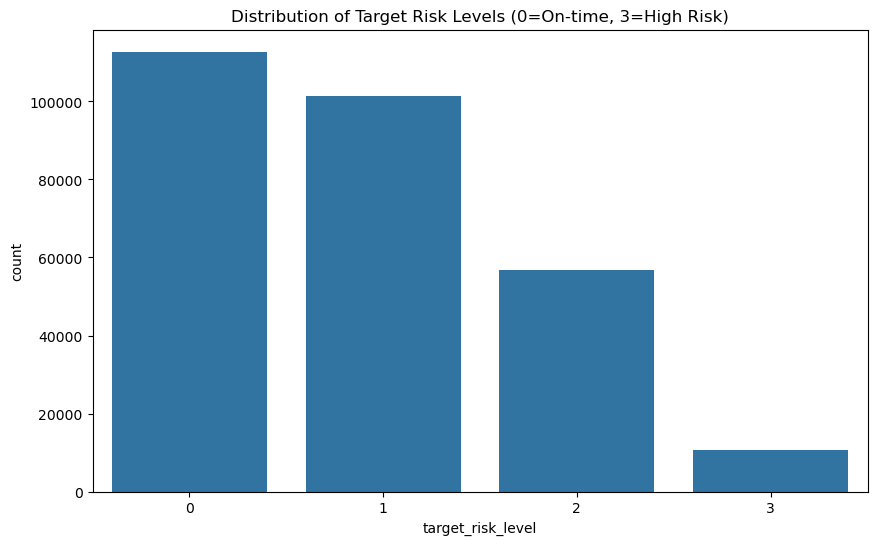

target_risk_level
0    0.400637
1    0.360009
2    0.201940
3    0.037413
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target_risk_level')
plt.title("Distribution of Target Risk Levels (0=On-time, 3=High Risk)")
plt.show()

print(df['target_risk_level'].value_counts(normalize=True))

Target (target_risk_level) shows clear class imbalance:
- Class 0 (On-time): ~40.1%
- Class 1 (Minor Risk): ~36.0%
- Class 2 (Major Risk): ~20.2%
- Class 3 (High Risk): ~3.7%

Implication: We should use class weights or SMOTE during modeling to avoid bias toward the majority “On-time” class.

### Delay Rate by Carrier & Airport (Top contributors)

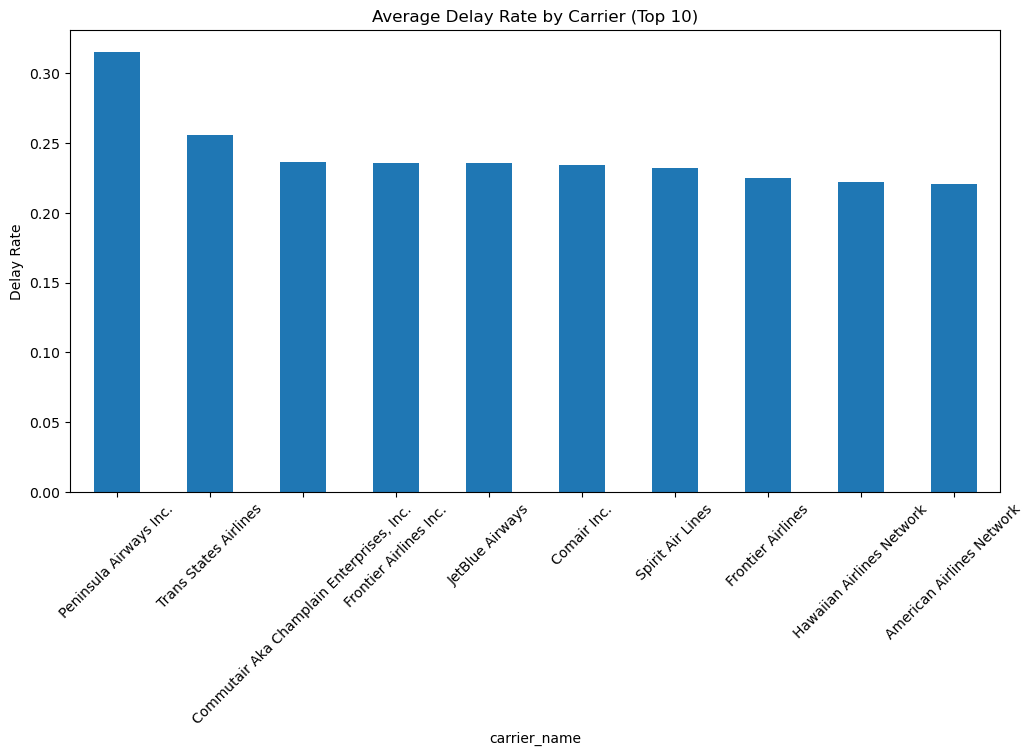

In [15]:
carrier_delay = df.groupby('carrier_name')['delay_rate'].mean().sort_values(ascending=False)
# Top 10 Carriers by delay rate
plt.figure(figsize=(12, 6))
carrier_delay.head(10).plot(kind='bar')
plt.title("Average Delay Rate by Carrier (Top 10)")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.show()

# Top 10 Airports
airport_delay = df.groupby('airport_name')['delay_rate'].mean().sort_values(ascending=False)

- Significant variation across carriers. Top delay-prone carriers (e.g., Frontier, Spirit, JetBlue) have noticeably higher average delay rates.
- Airports also vary widely — this validates the importance of carrier × airport interaction features.

### Correlation Analysis

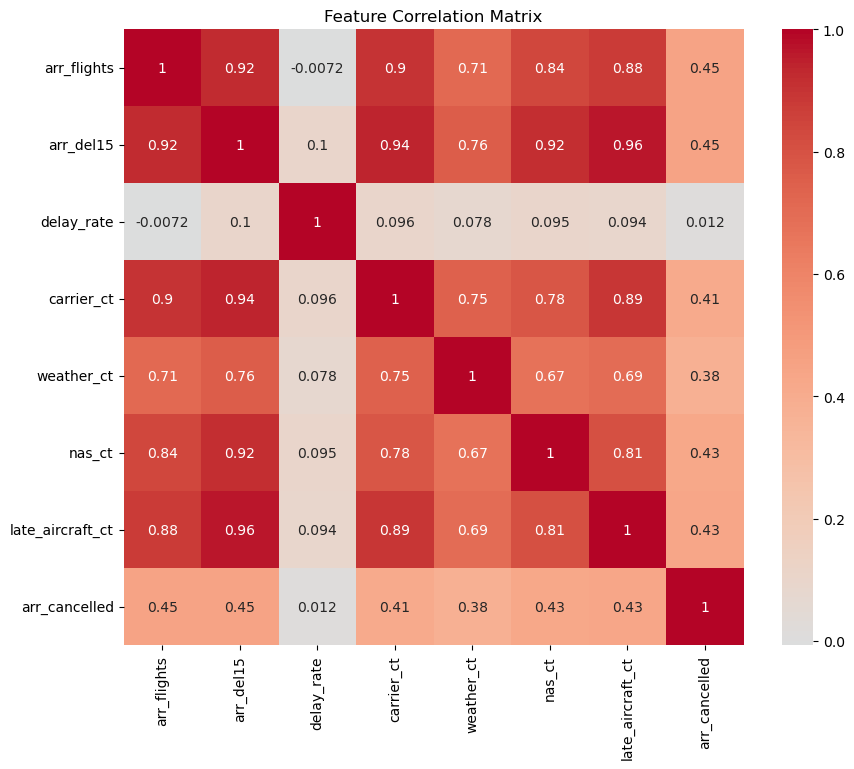

In [16]:
numeric_cols = ['arr_flights', 'arr_del15', 'delay_rate', 'carrier_ct', 'weather_ct', 
                'nas_ct', 'late_aircraft_ct', 'arr_cancelled']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

- **Strong positive correlations**:
    - arr_del15 with delay causes (carrier_ct, late_aircraft_ct, nas_ct).
    - Flight volume (arr_flights) strongly correlates with absolute delay counts.

- delay_rate has **moderate correlation** with most causes → supports our feature engineering plan.

### Temporal Patterns

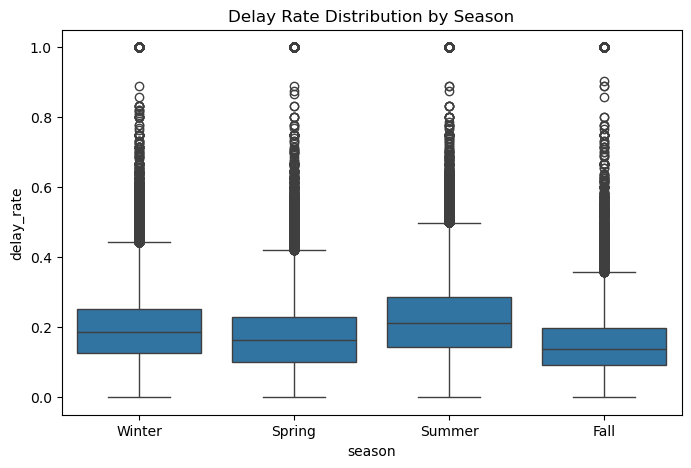

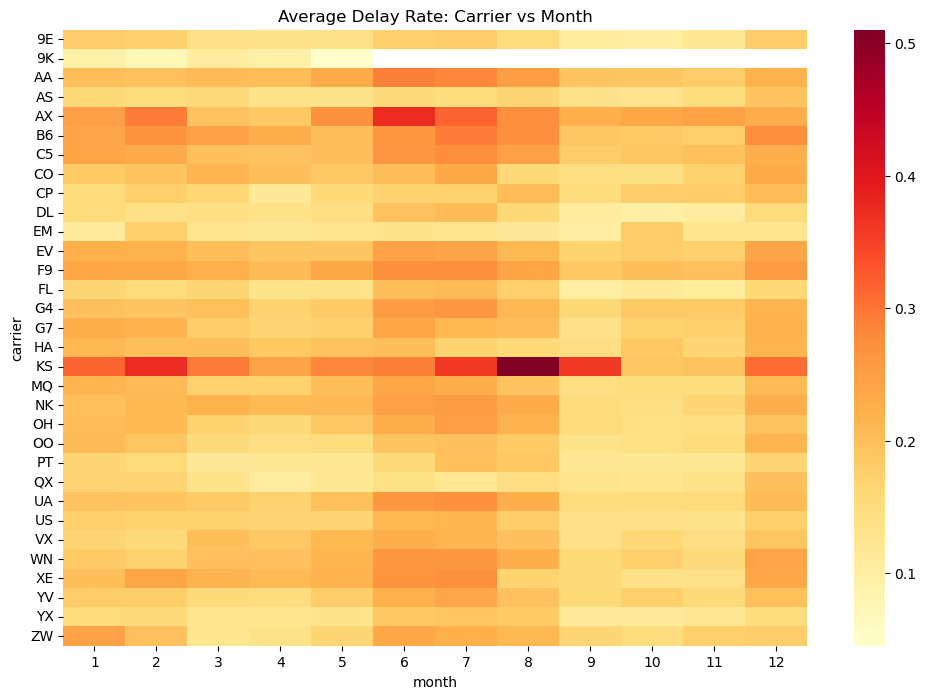

In [17]:
# Delay rate by Season
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='season', y='delay_rate')
plt.title("Delay Rate Distribution by Season")
plt.show()

# Heatmap: Carrier x Month
pivot = df.pivot_table(index='carrier', columns='month', values='delay_rate', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title("Average Delay Rate: Carrier vs Month")
plt.show()

- Seasonality: Higher delay rates in Summer and Winter (holiday/congestion peaks). Fall shows lowest delays.
- Carrier-month heatmap shows distinct seasonal patterns per airline → excellent signal for our model.

### Interaction Features & Lags

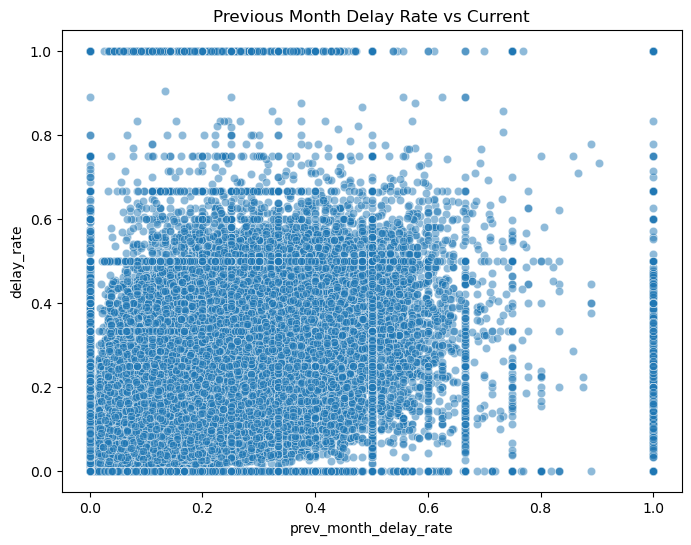

                       prev_month_delay_rate  delay_rate
prev_month_delay_rate               1.000000    0.429619
delay_rate                          0.429619    1.000000


In [18]:
# Check usefulness of lag feature
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='prev_month_delay_rate', y='delay_rate', alpha=0.5)
plt.title("Previous Month Delay Rate vs Current")
plt.show()

print(df[['prev_month_delay_rate', 'delay_rate']].corr())

- Previous month delay rate has strong correlation (0.43) with current delay rate → lagged features are highly predictive.
- Rolling 3-month average will further stabilize temporal signals.

### Outliers & Volume Analysis

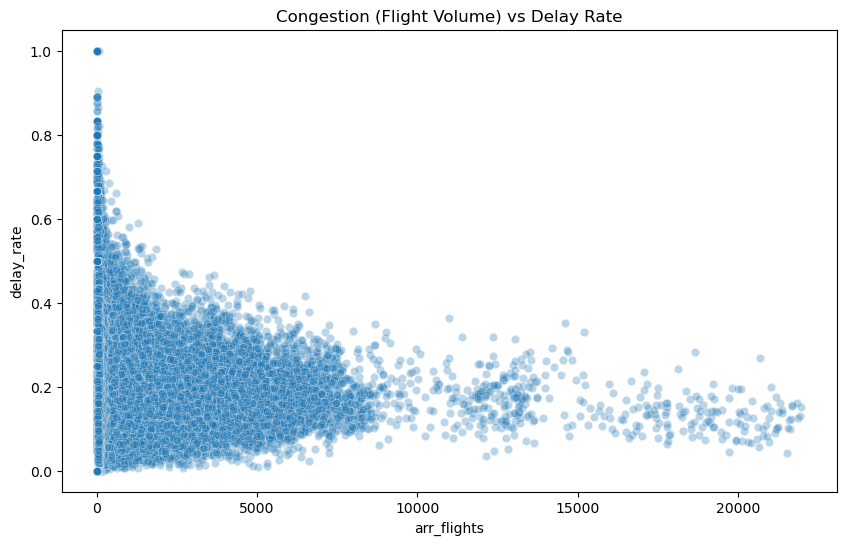

In [19]:
# Flights volume vs delay rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='arr_flights', y='delay_rate', alpha=0.3)
plt.title("Congestion (Flight Volume) vs Delay Rate")
plt.show()

- Weak negative relationship between flight volume and delay rate (larger operations tend to be slightly more efficient).
- Some high-volume outliers exist, worth monitoring during modeling.

### Delay Causes Breakdown and Monthly Trends

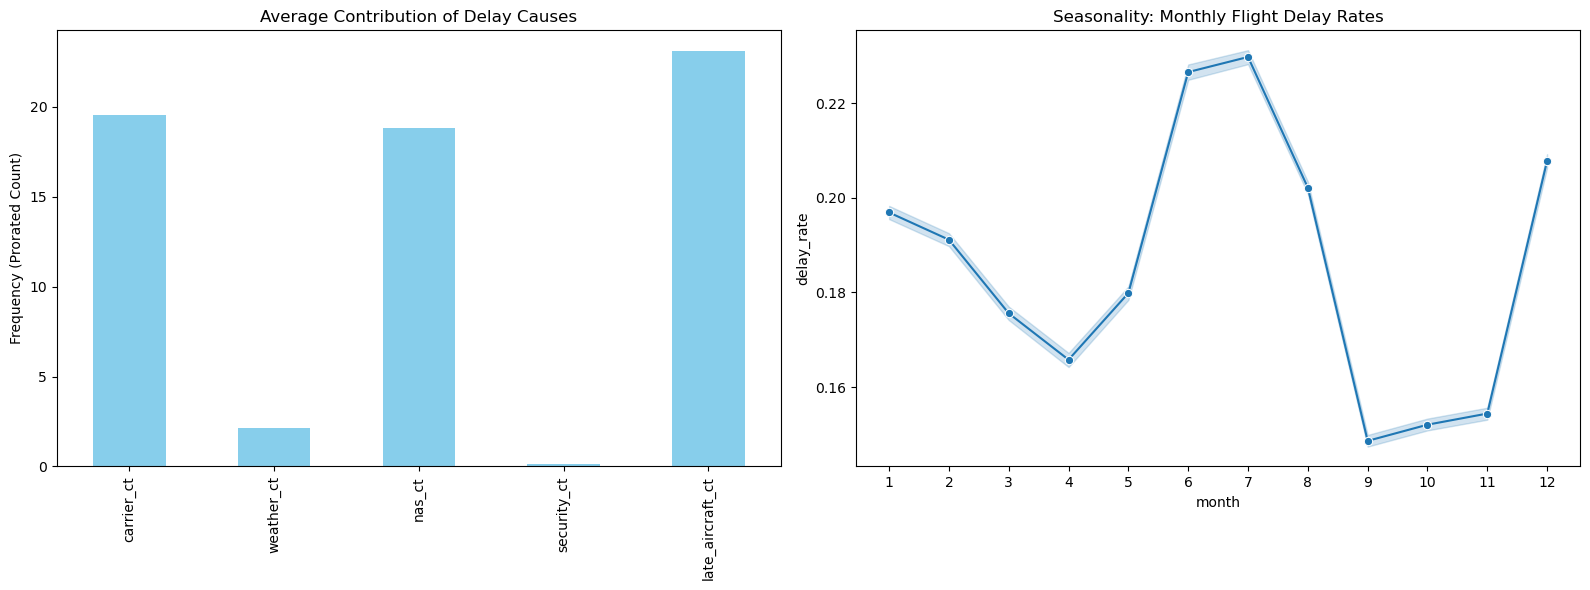

In [20]:
plt.figure(figsize=(16, 6))

# Plot 1: Delay Causes Breakdown (Carrier vs Weather vs NAS vs Late Aircraft)
plt.subplot(1, 2, 1)
cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
df[cause_cols].mean().plot(kind='bar', color='skyblue')
plt.title("Average Contribution of Delay Causes")
plt.ylabel("Frequency (Prorated Count)")

# Plot 2: Monthly Trends (Seasonality)
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='month', y='delay_rate', marker='o')
plt.title("Seasonality: Monthly Flight Delay Rates")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

- Dominant causes: Late Aircraft and NAS (National Airspace System).
- Weather and Security have much lower contribution.
- This explains why proactive prediction is valuable, many delays are systemic rather than random.

### COVID-19 Impact EDA (The "Corona" Analysis)

/tmp/ipykernel_3647/3405578397.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_stats, x='year', y='arr_flights', palette='Blues_d')


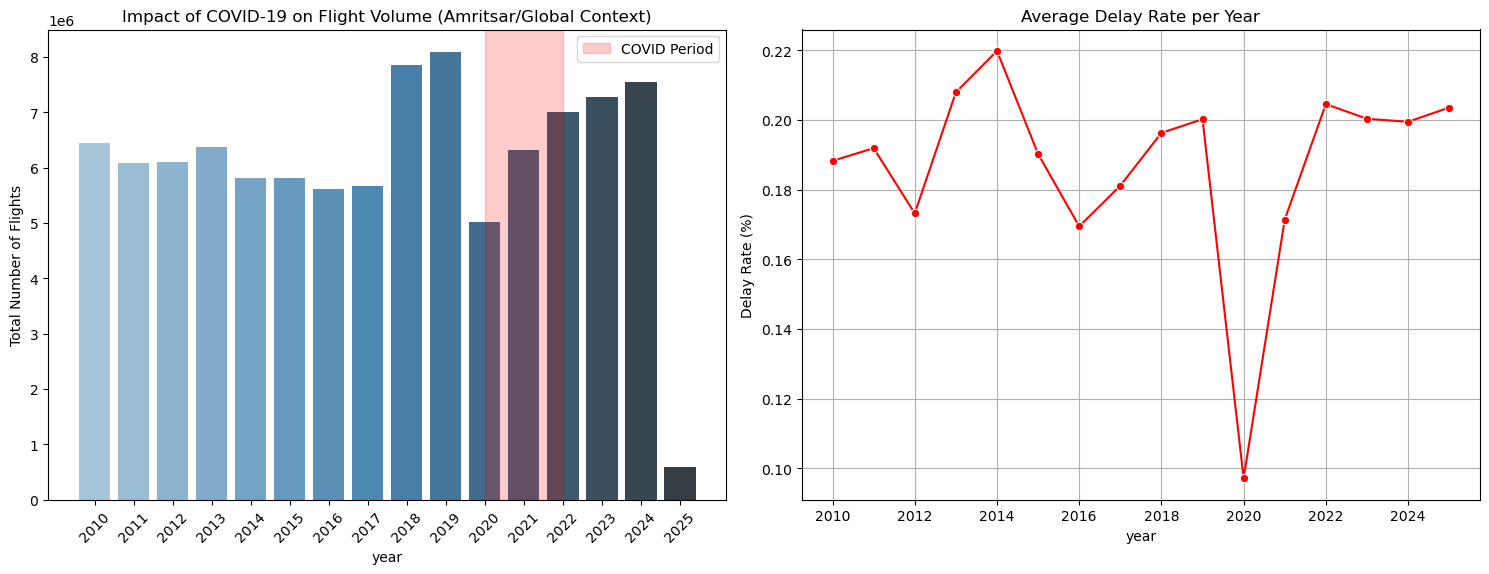

Observation: Flight volume dropped by ~50% in 2020. This is why 2019-2021 is our Validation set.


In [21]:
# Yearly Summary to visualize the COVID dip
yearly_stats = df.groupby('year').agg({
    'arr_flights': 'sum',
    'delay_rate': 'mean'
}).reset_index()

plt.figure(figsize=(15, 6))

# Plot A: Total Flight Volume (Shows the massive drop in 2020)
plt.subplot(1, 2, 1)
sns.barplot(data=yearly_stats, x='year', y='arr_flights', palette='Blues_d')
plt.title("Impact of COVID-19 on Flight Volume (Amritsar/Global Context)")
plt.xticks(rotation=45)
plt.ylabel("Total Number of Flights")
plt.axvspan(10, 12, color='red', alpha=0.2, label='COVID Period') # Highlights 2019-2021
plt.legend()

# Plot B: Delay Rate Trends
plt.subplot(1, 2, 2)
sns.lineplot(data=yearly_stats, x='year', y='delay_rate', marker='o', color='red')
plt.title("Average Delay Rate per Year")
plt.ylabel("Delay Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Observation: Flight volume dropped by ~50% in 2020. This is why 2019-2021 is our Validation set.")

- Massive drop in flight volume in 2020 (~50% reduction).
- Delay rates were unusually low during peak COVID years.
- Validation set (2019–2021) is well-chosen to test model robustness against distribution shift.

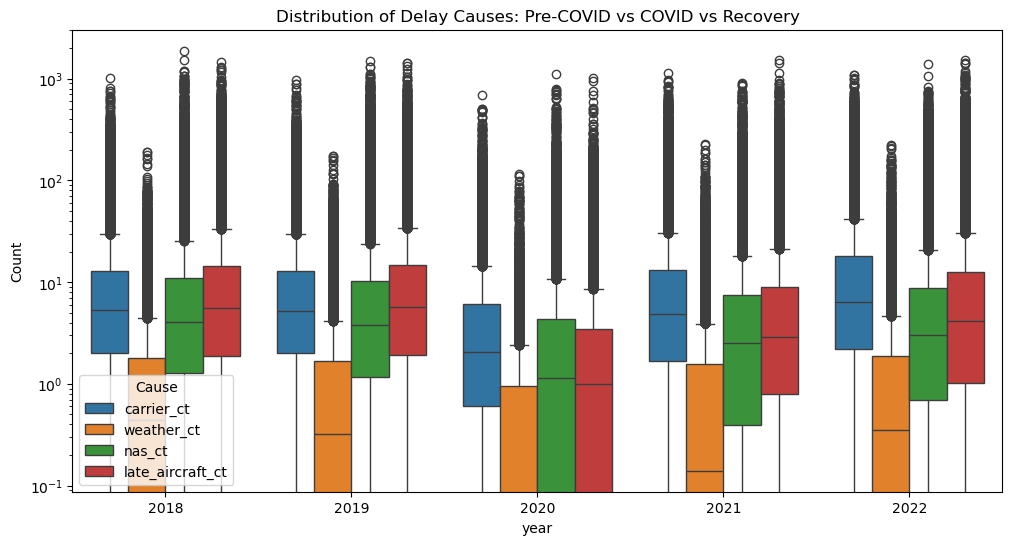

In [22]:
covid_df = df[(df['year'] >= 2018) & (df['year'] <= 2022)] # Narrow window around COVID

plt.figure(figsize=(12, 6))
causes = ['carrier_ct', 'weather_ct', 'nas_ct', 'late_aircraft_ct']
df_melted = covid_df.melt(id_vars=['year'], value_vars=causes, var_name='Cause', value_name='Count')

sns.boxplot(data=df_melted, x='year', y='Count', hue='Cause')
plt.title("Distribution of Delay Causes: Pre-COVID vs COVID vs Recovery")
plt.yscale('log')
plt.show()

- Late Aircraft and NAS (National Airspace System) are consistently the dominant delay causes across all years.
- During peak COVID (2020):
    - Overall delay counts dropped significantly (visible as lower boxes).
    - Carrier-caused delays and Late Aircraft delays reduced sharply — likely due to massive flight cancellations and reduced schedules.
    - Weather-related delays remained relatively stable (less affected by reduced operations).

- 2021 (Recovery year) shows a rebound in delay counts, especially in NAS and Late Aircraft, as flight volumes increased rapidly while operational capacity lagged.
- 2022 returns to pre-COVID patterns but at slightly higher levels.

## Temporal Data Splitting

In [23]:
# Load the latest processed file
df_final = pd.read_csv(f"{PROCESSED_DATA_URI}/processed_skyaware_data.csv")

# Temporal Split (Prevents Data Leakage)
train = df_final[df_final['year'] <= 2018]
val = df_final[(df_final['year'] >= 2019) & (df_final['year'] <= 2021)]
test = df_final[df_final['year'] >= 2022]

print("Final Data Split Summary:")
print(f"Training Set     : {train.shape[0]:,} records (2010–2018)")
print(f"Validation Set   : {val.shape[0]:,} records (2019–2021 - COVID robustness)")
print(f"Test Set         : {test.shape[0]:,} records (2022–2025)")

# Store variables for use in next notebooks (SageMaker Studio / Notebook Instances)
%store train
%store val
%store test
%store PROCESSED_DATA_URI

print("Variables stored successfully for next phase.")

Final Data Split Summary:
Training Set     : 140,835 records (2010–2018)
Validation Set   : 70,534 records (2019–2021 - COVID robustness)
Test Set         : 70,110 records (2022–2025)
Stored 'train' (DataFrame)


Stored 'val' (DataFrame)
Stored 'test' (DataFrame)
Stored 'PROCESSED_DATA_URI' (str)
Variables stored successfully for next phase.


### Save Processed Data to S3

In [24]:
df.to_csv("processed_skyaware_data.csv", index=False)
!aws s3 cp processed_skyaware_data.csv {PROCESSED_DATA_URI}/processed_skyaware_data.csv
print(f"Final processed dataset saved to: {PROCESSED_DATA_URI}")

Completed 1.0 MiB/58.6 MiB (10.6 MiB/s) with 1 file(s) remaining
Completed 2.0 MiB/58.6 MiB (20.4 MiB/s) with 1 file(s) remaining
Completed 3.0 MiB/58.6 MiB (29.9 MiB/s) with 1 file(s) remaining
Completed 4.0 MiB/58.6 MiB (39.1 MiB/s) with 1 file(s) remaining
Completed 5.0 MiB/58.6 MiB (48.0 MiB/s) with 1 file(s) remaining
Completed 6.0 MiB/58.6 MiB (56.5 MiB/s) with 1 file(s) remaining
Completed 7.0 MiB/58.6 MiB (64.5 MiB/s) with 1 file(s) remaining


Completed 9.0 MiB/58.6 MiB (48.0 MiB/s) with 1 file(s) remaining
Completed 10.0 MiB/58.6 MiB (52.9 MiB/s) with 1 file(s) remaining
Completed 11.0 MiB/58.6 MiB (57.3 MiB/s) with 1 file(s) remaining
Completed 12.0 MiB/58.6 MiB (61.9 MiB/s) with 1 file(s) remaining
Completed 13.0 MiB/58.6 MiB (65.5 MiB/s) with 1 file(s) remaining
Completed 14.0 MiB/58.6 MiB (70.5 MiB/s) with 1 file(s) remaining
Completed 15.0 MiB/58.6 MiB (73.7 MiB/s) with 1 file(s) remaining
Completed 16.0 MiB/58.6 MiB (77.9 MiB/s) with 1 file(s) remaining
Completed 17.0 MiB/58.6 MiB (81.4 MiB/s) with 1 file(s) remaining
Completed 17.6 MiB/58.6 MiB (83.3 MiB/s) with 1 file(s) remaining
Completed 18.6 MiB/58.6 MiB (87.7 MiB/s) with 1 file(s) remaining
Completed 19.6 MiB/58.6 MiB (91.6 MiB/s) with 1 file(s) remaining
Completed 20.6 MiB/58.6 MiB (96.3 MiB/s) with 1 file(s) remaining
Completed 21.6 MiB/58.6 MiB (100.1 MiB/s) with 1 file(s) remaining
Completed 22.6 MiB/58.6 MiB (102.8 MiB/s) with 1 file(s) remaining
Completed

Completed 27.6 MiB/58.6 MiB (120.6 MiB/s) with 1 file(s) remaining
Completed 28.6 MiB/58.6 MiB (123.9 MiB/s) with 1 file(s) remaining
Completed 29.6 MiB/58.6 MiB (126.8 MiB/s) with 1 file(s) remaining
Completed 30.6 MiB/58.6 MiB (130.9 MiB/s) with 1 file(s) remaining
Completed 31.6 MiB/58.6 MiB (134.0 MiB/s) with 1 file(s) remaining
Completed 32.6 MiB/58.6 MiB (138.0 MiB/s) with 1 file(s) remaining
Completed 33.6 MiB/58.6 MiB (142.2 MiB/s) with 1 file(s) remaining
Completed 34.6 MiB/58.6 MiB (144.5 MiB/s) with 1 file(s) remaining
Completed 35.6 MiB/58.6 MiB (147.6 MiB/s) with 1 file(s) remaining
Completed 36.6 MiB/58.6 MiB (150.2 MiB/s) with 1 file(s) remaining
Completed 37.6 MiB/58.6 MiB (153.1 MiB/s) with 1 file(s) remaining
Completed 38.6 MiB/58.6 MiB (156.2 MiB/s) with 1 file(s) remaining
Completed 39.6 MiB/58.6 MiB (160.1 MiB/s) with 1 file(s) remaining
Completed 40.6 MiB/58.6 MiB (161.8 MiB/s) with 1 file(s) remaining
Completed 41.6 MiB/58.6 MiB (165.5 MiB/s) with 1 file(s) remai

Completed 57.6 MiB/58.6 MiB (205.7 MiB/s) with 1 file(s) remaining


upload: ./processed_skyaware_data.csv to s3://sagemaker-us-east-1-395523713934/skyaware-processed-data/processed_skyaware_data.csv


Final processed dataset saved to: s3://sagemaker-us-east-1-395523713934/skyaware-processed-data
